# DASC 400 Bird Call Project
### Breanna Ranglall & Ibuki Washburn

In [1]:
# run these if don't have them installed
#!pip install optuna
#!pip install tensorflow

In [7]:
# standard libraries
import numpy as np
import pandas as pd
import warnings
warnings.simplefilter('ignore')
import gc

# Visualize training history
import matplotlib.pyplot as plt
%matplotlib inline

# tensorflow
import tensorflow as tf
from tensorflow import keras
from tqdm.keras import TqdmCallback

# optuna
import optuna

# sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

## Introduction & Motivation

Automated recognition of bird species from their vocalisations has become an attractive research problem because it blends ecological monitoring with modern machine-learning techniques. Inspired by Cornell Lab’s highly regarded Birdsong Recognition competition, we set out to build a classifier that can identify species using only short audio clips. Besides heeding Dr Werness’s suggestion that this would make an engaging final project, we were eager to gain hands-on experience with audio feature engineering—a skill that transfers to many domains, from speech analytics to bioacoustics.

## Exploratory Data Analysis & Project Goals

Preliminary EDA confirmed that class imbalance is substantial, several rare species appear fewer than ten times, making naïve accuracy misleading. Accordingly, our four goals were:

1. Understand the latent structure of the feature space (clusters or outliers).

2. Prototype at least one traditional and two neural models.

3. Tune hyperparameters systematically to squeeze out extra accuracy.

4. Evaluate fairly on a held-out test set and document shortcomings for future work.

In [8]:
df = pd.read_csv('dataset.csv')

# Drop filename column
df = df.drop(columns=['filename'])

# Convert columns with bird names to numerical code
le = LabelEncoder()
df['label'] = le.fit_transform(df['label'])

df.groupby('label').filter(lambda x : len(x)>10)
sub_df = df[df.groupby('label').label.transform('count')>10].copy()

# view
sub_df

,chroma_stft,rms,spectral_centroid,spectral_bandwidth,rolloff,zero_crossing_rate,mfcc1,mfcc2,mfcc3,mfcc4,...,mfcc12,mfcc13,mfcc14,mfcc15,mfcc16,mfcc17,mfcc18,mfcc19,mfcc20,label
0,0.592959,0.008214,2756.314965,2671.700479,5803.582764,0.150738,-329.593048,77.796181,-11.007781,15.441154,...,4.675884,-4.270268,6.639040,-2.032491,3.748571,-1.192944,3.819380,-1.592449,4.146574,0
1,0.445633,0.011182,4849.245849,1960.078954,6962.341233,0.408716,-506.991882,-94.189995,-66.601006,21.418806,...,1.026675,-3.219575,5.016063,-2.692930,1.245947,-2.166367,2.367208,-3.187211,3.042730,0
2,0.491342,0.007226,4048.471445,2235.524317,6557.677013,0.302023,-477.984528,-121.129715,-145.713058,-26.852354,...,0.306044,-4.073335,1.470622,-2.557777,2.980418,1.284922,5.729064,-2.983708,1.832972,0
3,0.555491,0.016315,4327.569353,2846.678935,7981.648952,0.347925,-315.947571,17.248848,-24.313393,8.431483,...,-0.374923,-6.571611,2.610246,-5.446579,-3.616137,-4.213018,-1.368571,-5.277973,0.475844,0
4,0.687489,0.071456,3634.945700,2473.898862,6342.327588,0.284439,-72.725365,33.178391,-35.684204,21.969164,...,5.084502,1.275231,4.249923,-4.074911,2.886948,-6.306517,4.148955,-5.137774,5.145658,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12360,0.422929,0.032790,2830.771223,2640.725111,5853.490556,0.141361,-254.950470,66.365486,-20.901850,-6.480114,...,-12.614041,-19.589306,-11.288402,-13.606933,-7.365254,-12.567055,-6.225912,-9.425448,-1.914419,147
12361,0.456022,0.038203,1454.968344,1755.409715,2565.192060,0.065938,-262.680817,129.147415,-41.884510,2.371792,...,9.449895,6.690379,13.339852,9.990253,14.080956,5.101741,11.511769,3.362309,7.456527,147
12362,0.541382,0.059542,2967.904198,1894.794915,5064.919373,0.205536,-159.406158,3.195026,-129.160080,-20.913094,...,5.464991,2.559317,11.329490,4.002252,6.594406,0.244300,3.474930,-2.202893,5.819273,147
12363,0.640628,0.023386,1156.133090,2069.722985,1551.713326,0.038406,-312.113617,158.666107,42.628853,-6.432523,...,5.457233,-2.644947,1.938845,-1.334749,2.063163,-4.875724,1.170730,-3.790732,1.553186,147


##  Bird Brain Background and Dataset

Rather than processing the original gigabytes of MP3 files, we leveraged the birdcalldataset Kaggle subset, which already converts each recording into a single row of tabular features. This document summarizes background research on the variables in this dataset:  
https://www.kaggle.com/datasets/ladanova/birdcalldataset/data  
(based on the competition dataset: https://www.kaggle.com/c/birdsong-recognition/data)

---

###  Variables

- `chroma_stft` (Chroma Short-Time Fourier Transform) – spectral
- `rms` (Root Mean Square Energy) – temporal
- `spectral_centroid` – spectral
- `spectral_bandwidth` – spectral
- `rolloff` – spectral
- `zero_crossing_rate` – temporal
- `mfcc1` through `mfcc20` (Mel-Frequency Cepstral Coefficients) – unique

---

###  Chroma_STFT (Chroma Short-Time Fourier Transform)

Source:
- https://www.sciencedirect.com/topics/engineering/continuous-time-fourier-transform
- https://www.audiolabs-erlangen.de/content/05_fau/professor/00_mueller/02_teaching/2019w_mpa/2019_Mueller_MP-AudioFeatures_6.pdf


This is a 12-dimensional representation showing the energy across 12 pitch classes (C, C#, ..., B), **independent of octave**.

####  Mathematical Steps:
1. Create a time window (possibly 1 ms).
2. Apply a smoothing function.
3. Apply the **Discrete-Time Fourier Transform (DTFT)** or **Fast Fourier Transform (FFT)** to get a frequency spectrum.
4. Use chroma binning on a log scale to reduce to 12 pitch class bins (e.g., A♯, C♭).
5. Normalize the resulting vector.

→ If we check our dataset and see just 1 number, they probably summarized the chroma vector using:
- Mean value,
- Index of dominant pitch class,
- Or total chroma energy (if unnormalized).

---

###  RMS (Root Mean Square Energy)

Source: https://unison.audio/what-is-rms-in-audio/

- Measures the **average power** of the audio signal over time.

$$ \text{RMS} = \sqrt{ \frac{1}{N} \sum_{n=1}^{N} x[n]^2 } $$

- \( x[n] \) is a digital sample (also written as \( x_n \)).
- So: \( x[n]^2 = x_n^2 \)

- In formulas:  
  If \( x[n] \) is a signal in discrete time, then RMS is based on \( x[n]^2 \).

---

###  Spectral Centroid

Source: https://www.mathworks.com/help/audio/ug/spectral-descriptors.html

- Represents the **center of mass** of the spectrum.
- Related to the **brightness** of sound: higher frequencies → higher centroid.
- In equations:
- $
\text{Centroid} = \frac{ \sum_k f[k] \cdot S[k] }{ \sum_k S[k] }
$

  where \( f \) is frequency, \( S \) is magnitude. Averaged across the frequency bins.

---

###  Spectral Bandwidth (Spectral Spread)

Source: https://www.mathworks.com/help/audio/ug/spectral-descriptors.html

- Measures how spread-out (or the variance of) the frequencies are around the **spectral centroid**.
- Equation resembles the **standard deviation** formula of the spectrum around the centroid.

$
\mu_2 = \frac{ \sum_{k = b_1}^{b_2} (f_k - \mu_1)^2 \cdot s_k }{ \sum_{k = b_1}^{b_2} s_k }
$

Where:

- \( f_k \): frequency in Hz for bin \( k \)  
- \( s_k \): spectral value at bin \( k \)  
- \( b_1, b_2 \): start and end bin indices  
- \( \mu_1 \): spectral centroid  

---

###  Spectral Rolloff

Source: https://www.mathworks.com/help/audio/ug/spectral-descriptors.html

- Indicates **what frequency** contains a given percentage \( k \) of the total spectral energy.
- Used to estimate **bandwidth concentration** toward lower or higher frequencies.


$
\text{Rolloff Point} = i \quad \text{such that} \quad \sum_{k=1}^{i} |s_k| = k \sum_{k=1}^{b_2} s_k
$

Where:

- \( s_k \): spectral value at bin \( k \)  
- \( b_1 \), \( b_2 \): the lower and upper frequency bins considered  
- \( k \): the chosen energy threshold (typically 85% or 95%)  
- \( i \): the rolloff bin index (converted to Hz later)  

 **Interpretation**: This is the frequency below which a certain percentage \( k \) of the signal energy is concentrated — i.e., how much energy is packed into the lower frequencies.



---

###  Zero Crossing Rate

Source: https://medium.com/data-science/decoding-the-symphony-of-sound-audio-signal-processing-for-musical-engineering-c66f09a4d0f5

- Number of times the audio waveform **crosses the zero axis** (time domain).
- For frame \( k \), ZCR is defined mathematically as the count of sign changes.


$
\text{ZCR}_k = \sum_{i = kK}^{(k+1)K - 1} \frac{1}{2} \left| \text{sgn}(x_i) - \text{sgn}(x_{i+1}) \right|
$

With the sign function:

$
\text{sgn}(x) =
\begin{cases}
1 & \text{if } x > 0 \\\\
0 & \text{if } x = 0 \\\\
-1 & \text{if } x < 0
\end{cases}
$

Where:

- \( K \): frame size  
- \( x_i \): audio signal sample at index \( i \)  
- The ZCR measures how often the signal crosses zero in a frame.
---

###  MFCCs (Mel-Frequency Cepstral Coefficients)

Source: https://www.geeksforgeeks.org/mel-frequency-cepstral-coefficients-mfcc-for-speech-recognition/  

Includes: `mfcc1` through `mfcc20`.

- “The Mel-scale is specifically designed to mimic the way humans perceive sound, particularly how we discern differences in pitch. Human hearing is more sensitive to changes in lower frequencies than to equivalent changes in higher frequencies.”

- “The Mel-scale addresses this by applying a linear frequency spacing below 1000 Hz and a logarithmic spacing above 1000 Hz. This scaling allows for a more perceptually relevant representation of audio signals, aligning the scale with the non-linear human auditory system:”


#####  How to Compute MFCC?

Finally, by taking the first few coefficients from the DCT output, we obtain the MFCCs, which represent a compact and informative description of the speech signal in each frame.  
To calculate MFCCs, we follow these steps:

1. **Pre-emphasize the signal**: Amplify higher frequencies to balance the spectrum.  
2. **Framing**: Break the signal into small, overlapping frames.  
3. **Windowing**: To soften the edges of each frame, apply a Hamming window.  
4. **FFT**: Convert each frame from the time domain to the frequency domain.  
5. **Mel-filterbank**: Apply overlapping triangular filters spaced according to the Mel-scale.  
6. **Logarithm**: To replicate how a human ear reacts to sound strength, take the logarithm of the filterbank outputs.  
7. **DCT**: Apply the Discrete Cosine Transform (DCT) to the log Mel-spectrum to obtain the **Mel-frequency Cepstral Coefficients**.

---

###  Calculating MFCCs from Speech Signal in Python

In this example, we'll go over how to use Python to calculate the MFCCs from a speech signal.  
Common libraries like `librosa` for audio processing and `numpy`, `scipy`, and `matplotlib` will be used. Lastly, we'll utilize `ipywidgets` to build a basic GUI that will allow users to test the model in real time.

> **Pipeline**:  
> *Original Signal → Pre-emphasis → Framing → Windowing → FFT → Mel-filterbank → Logarithm → DCT → MFCCs*



---

###  Additional Sources and Notes

- https://ravinkumar.com/GenAiGuidebook/audio/audio_feature_extraction.html  
- https://citeseerx.ist.psu.edu/document?doi=30a90af7c214f423743472e0c82f2b5332ccb55f&repid=rep1&type=pdf
- https://quod.lib.umich.edu/cgi/p/pod/dod-idx/realtime-chord-recognition-of-musical-sound-a-system-using.pdf?c=icmc;idno=bbp2372.1999.446;format=pdf
- https://dsp-book.narod.ru/DSPMW/01.PDF
  Digital devices record time as discrete, the smallest unit is based on sampling rate. So all the math is discrete math.

## Baseline TensorFlow-Keras Model

We began with a simple feed-forward network in TensorFlow/Keras: input layer → single hidden layer (64 neurons, ReLU) → soft-max output. Using default optimiser settings and ten epochs, the model reached 12% accuracy on our test split. While low, it established a reproducible baseline that every subsequent model had to beat.

In [9]:
# Define our x and y variables
x, y = df.iloc[:,:-1], df[['label']]

# Train & Test Split Sataset
TEST_SIZE = 0.2
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=TEST_SIZE, random_state=0)
print(f"Training Records = {x_train.shape[0]} ; Validation Record {x_test.shape[0]} ")

#Training Records = 9892 ; Validation Record 2473

Training Records = 9892 ; Validation Record 2473 


In [10]:
x_train

,chroma_stft,rms,spectral_centroid,spectral_bandwidth,rolloff,zero_crossing_rate,mfcc1,mfcc2,mfcc3,mfcc4,...,mfcc11,mfcc12,mfcc13,mfcc14,mfcc15,mfcc16,mfcc17,mfcc18,mfcc19,mfcc20
621,0.440479,0.005111,2162.585738,2526.759310,4737.263021,0.101223,-417.821838,113.824593,11.122939,2.787136,...,-17.609716,-2.667444,-20.081846,-4.148600,-14.819472,-1.970634,-11.630307,-2.669508,-11.197052,-3.708732
1985,0.605277,0.005406,5092.913692,2930.986337,8573.431491,0.433683,-393.581909,-65.371605,-77.172226,-73.775177,...,9.740697,18.674625,13.734297,17.756245,8.687678,8.267630,-0.333717,-0.403508,-7.271578,-5.858856
10524,0.568138,0.003095,2142.251443,2016.187247,4331.248810,0.133130,-526.091980,94.103813,-5.154779,13.319344,...,4.955775,-1.060434,1.574171,-0.674774,4.782862,-4.751312,-0.938083,-3.299653,-3.838330,-1.657918
6319,0.450885,0.015743,2394.076619,2486.515315,5012.965777,0.117229,-330.676666,90.680550,-14.120644,-10.745285,...,-13.200012,-15.019937,-20.033657,-10.000556,-17.986622,-9.269392,-11.343246,-5.481420,-7.109539,-1.643835
5717,0.534410,0.013652,4170.954080,2768.201609,7484.463076,0.313831,-314.828522,23.064857,6.373902,33.616348,...,-0.526741,7.607011,0.860870,6.024037,1.263432,2.935883,-0.594346,4.815045,-1.778063,2.786066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4859,0.490133,0.081950,1422.822225,1598.235480,1876.334252,0.089898,-171.225494,148.169373,-39.605385,-47.172161,...,-24.607075,-9.488595,-16.605042,-3.717744,-7.649594,-11.252718,-14.659987,0.485906,-4.642930,-3.523590
3264,0.305088,0.026623,5037.394871,1907.935965,6963.666225,0.458555,-552.549805,-51.714577,-25.509594,31.540302,...,1.959439,-5.162507,2.119998,4.346972,-6.471492,5.340819,-2.245624,0.759028,-0.262111,-0.896107
9845,0.594676,0.003856,3900.500243,2112.401183,6116.263016,0.319115,-459.198730,-29.519228,-87.262619,4.921825,...,-17.777609,-5.178974,-7.547525,0.049585,-2.616215,-3.678914,-6.964491,0.557009,-5.447217,0.850083
10799,0.568030,0.029107,4043.170639,2600.638277,6778.175680,0.353236,-192.540207,27.879154,-22.375383,7.343925,...,-16.531845,-10.596206,-15.860592,-12.813120,-9.433982,-14.586206,-6.284613,-8.215002,-11.890099,2.791260


In [11]:
x_train.shape

#(9892, 26)

(9892, 26)

Parameters & Functions

In [12]:
# Params
INPUT_SHAPE = x_train.shape[1]
OUTPUT_SHAPE = len(np.unique(y_train))
NODES = np.ceil(2 * INPUT_SHAPE / 3 + OUTPUT_SHAPE).astype(int)
BATCH_SIZE = np.ceil(len(x_train) / 16).astype(int)
EPOCHS = 150
TRIALS = 25

In [13]:
# utility function to build model
def build_model(batch_size=None,nodes=None,input_shape=None,output_shape=None):
    model = keras.models.Sequential()
    model.add(keras.layers.Dense(batch_size, input_shape=(input_shape,), activation='relu'))
    model.add(keras.layers.Dense(nodes, activation='relu'))
    model.add(keras.layers.Dropout(0.5))
    model.add(keras.layers.Dense(output_shape, activation='softmax'))
    return model

# utility function plot curves
def plot_curves(hist):

    # create subplots
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))

    # plot accuracy curve
    ax[0].plot(hist.history['accuracy'])
    ax[0].plot(hist.history['val_accuracy'])
    ax[0].set_title('model accuracy')
    ax[0].set_xlabel('epoch')
    ax[0].set_ylabel('accuracy')
    ax[0].legend(['train', 'val'], loc='best')

    # plot loss curve
    ax[1].plot(hist.history['loss'])
    ax[1].plot(hist.history['val_loss'])
    ax[1].set_title('model loss')
    ax[1].set_xlabel('epoch')
    ax[1].set_ylabel('loss')
    ax[1].legend(['train', 'val'], loc='upper right')

    plt.show()

In [14]:
# baseline model
baseline_model = build_model(BATCH_SIZE,NODES,INPUT_SHAPE,OUTPUT_SHAPE)

# compile model
baseline_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# model summary
baseline_model.summary()

'''Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 619)            │        16,713 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 166)            │       102,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 166)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 148)            │        24,716 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 144,349 (563.86 KB)
 Trainable params: 144,349 (563.86 KB)
 Non-trainable params: 0 (0.00 B)
'''

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 619)            │        16,713 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 166)            │       102,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 166)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 148)            │        24,716 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,349 (563.86 KB)

 Trainable params: 144,349 (563.86 KB)

 Non-trainable params: 0 (0.00 B)

'Model: "sequential"\n┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓\n┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃\n┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩\n│ dense (Dense)                   │ (None, 619)            │        16,713 │\n├─────────────────────────────────┼────────────────────────┼───────────────┤\n│ dense_1 (Dense)                 │ (None, 166)            │       102,920 │\n├─────────────────────────────────┼────────────────────────┼───────────────┤\n│ dropout (Dropout)               │ (None, 166)            │             0 │\n├─────────────────────────────────┼────────────────────────┼───────────────┤\n│ dense_2 (Dense)                 │ (None, 148)            │        24,716 │\n└─────────────────────────────────┴────────────────────────┴───────────────┘\n Total params: 144,349 (563.86 KB)\n Trainable params: 144,349 (563.86 KB)\n Non-trainable params: 0 (0.00 B)\n'

0epoch [00:00, ?epoch/s]

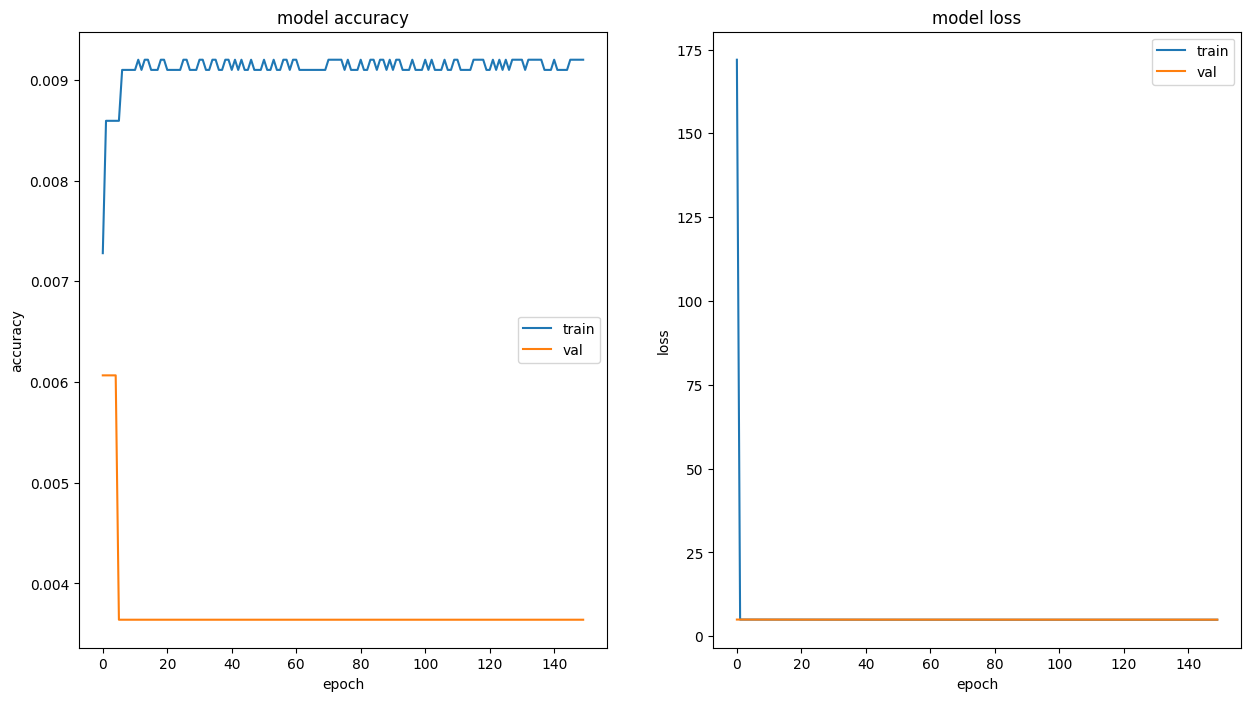

In [15]:
# clear session
tf.keras.backend.clear_session()

# train model
baseline_hist = baseline_model.fit(x_train
          , y_train
          , epochs = EPOCHS
          , batch_size=BATCH_SIZE
          ,shuffle=True
          ,validation_data=(x_test, y_test)
          ,verbose=0
          ,callbacks=[TqdmCallback(verbose=0)]
          )

# plot
plot_curves(baseline_hist)

#150/150 [01:35<00:00,  1.83epoch/s, accuracy=0.0091, loss=4.95, val_accuracy=0.00364, val_loss=4.96]

## Optuna-Tuned TensorFlow-Keras Model

Recognising that neural nets live or die by their hyperparameters, we wrapped the Keras architecture in Optuna for Bayesian hyperparameter optimisation. Search ranges were:

* hidden layers: 1–128

* nodes per layer: 1–128

* learning rate: 1e-4–0.1

* batch size: 8, 16, 32, 64

Optuna launched multiple “studies,” each comprising dozens of trials; after every trial the validation loss was returned so the posterior could steer the next parameter proposal away from likely local minima. The best configuration—two hidden layers of 96 and 48 neurons, learning rate 0.003, batch size 32—raised accuracy to ~16%, a modest gain over the baseline but still below our next approach.

In [16]:
# utility function to create model trials
def create_model(trial):
    # We optimize the numbers of layers, their units and learning rates
    n_layers = trial.suggest_int("n_layers", 1, 5)
    n_nodes = trial.suggest_int('n_nodes', 8, 64)
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-1)

    # build model
    model = keras.models.Sequential()

    # add input layer
    model.add(keras.layers.Dense(BATCH_SIZE, input_shape=(INPUT_SHAPE,), activation='relu'))

    # dynamically add hidden layers through trial
    for i in range(n_layers):
        model.add(keras.layers.Dense(n_nodes, activation='relu'))

    # add dropout layer
    model.add(keras.layers.Dropout(0.5))

    # add output layer
    model.add(keras.layers.Dense(OUTPUT_SHAPE,activation='softmax'))

    # compile the model
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  metrics=['accuracy'])

    return model

# Objective function
def objective(trial):

    # instantiate model
    model_opt = create_model(trial)

    # fit the model
    model_opt.fit(x_train
                  ,y_train
                  ,epochs = EPOCHS
                  ,batch_size=BATCH_SIZE
                  ,shuffle=True
                  ,validation_data=(x_test, y_test)
                  ,verbose=0
                  ,callbacks=[TqdmCallback(verbose=0)])
    # calculate accuracy score
    acc_score = model_opt.evaluate(x_test, y_test, verbose=0)[1]

    return acc_score


In [17]:
# perform the optimization
study = optuna.create_study(direction="maximize", study_name="baseline model optimization")
study.optimize(objective, n_trials=TRIALS, n_jobs=-1)

#[I 2025-05-08 18:37:11,927] Trial 24 finished with value: 0.01698342151939869 and parameters: {'n_layers': 5, 'n_nodes': 38, 'learning_rate': 5.3972065014489795e-05}. Best is trial 6 with value: 0.02224019356071949.

[I 2025-05-22 19:44:28,948] A new study created in memory with name: baseline model optimization


0epoch [00:00, ?epoch/s]

0epoch [00:00, ?epoch/s]

[I 2025-05-22 19:45:51,662] Trial 0 finished with value: 0.0056611401960253716 and parameters: {'n_layers': 2, 'n_nodes': 29, 'learning_rate': 0.09780253813116564}. Best is trial 0 with value: 0.0056611401960253716.


0epoch [00:00, ?epoch/s]

...

[I 2025-05-22 19:59:07,832] Trial 21 finished with value: 0.005256772972643375 and parameters: {'n_layers': 3, 'n_nodes': 52, 'learning_rate': 7.274221148011322e-05}. Best is trial 4 with value: 0.05418520048260689.


0epoch [00:00, ?epoch/s]

[I 2025-05-22 20:00:01,290] Trial 22 finished with value: 0.003639304544776678 and parameters: {'n_layers': 5, 'n_nodes': 8, 'learning_rate': 6.952091443513464e-05}. Best is trial 4 with value: 0.05418520048260689.


0epoch [00:00, ?epoch/s]

[I 2025-05-22 20:00:12,450] Trial 23 finished with value: 0.012939749285578728 and parameters: {'n_layers': 5, 'n_nodes': 11, 'learning_rate': 7.284686926012155e-05}. Best is trial 4 with value: 0.05418520048260689.
[I 2025-05-22 20:00:51,531] Trial 24 finished with value: 0.020622724667191505 and parameters: {'n_layers': 5, 'n_nodes': 15, 'learning_rate': 8.808407613160382e-05}. Best is trial 4 with value: 0.05418520048260689.


In [18]:
# print out
print('*'*100)
print("Number of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial
print("  Value: ", trial.value)
print("Best Params:")
print(study.best_params)
print('*'*100)

'''
****************************************************************************************************
Number of finished trials:  25
Best trial:
  Value:  0.02224019356071949
Best Params:
{'n_layers': 5, 'n_nodes': 18, 'learning_rate': 0.00027485461202513407}
****************************************************************************************************
'''

****************************************************************************************************
Number of finished trials:  25
Best trial:
  Value:  0.05418520048260689
Best Params:
{'n_layers': 5, 'n_nodes': 41, 'learning_rate': 0.0007583383416384022}
****************************************************************************************************


"\n****************************************************************************************************\nNumber of finished trials:  25\nBest trial:\n  Value:  0.02224019356071949\nBest Params:\n{'n_layers': 5, 'n_nodes': 18, 'learning_rate': 0.00027485461202513407}\n****************************************************************************************************\n"

In [19]:
# get the optimized model
baseline_model_opt = create_model(study.best_trial)
baseline_model_opt.summary()

'''
Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 619)            │        16,713 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │        11,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 18)             │           342 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 18)             │           342 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 18)             │           342 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 18)             │           342 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 148)            │         2,812 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 32,053 (125.21 KB)
 Trainable params: 32,053 (125.21 KB)
 Non-trainable params: 0 (0.00 B)
 '''

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 619)            │        16,713 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 41)             │        25,420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 41)             │         1,722 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 41)             │         1,722 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 41)             │         1,722 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 41)             │         1,722 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 41)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 148)            │         6,216 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,237 (215.77 KB)

 Trainable params: 55,237 (215.77 KB)

 Non-trainable params: 0 (0.00 B)

'\nModel: "sequential"\n┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓\n┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃\n┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩\n│ dense (Dense)                   │ (None, 619)            │        16,713 │\n├─────────────────────────────────┼────────────────────────┼───────────────┤\n│ dense_1 (Dense)                 │ (None, 18)             │        11,160 │\n├─────────────────────────────────┼────────────────────────┼───────────────┤\n│ dense_2 (Dense)                 │ (None, 18)             │           342 │\n├─────────────────────────────────┼────────────────────────┼───────────────┤\n│ dense_3 (Dense)                 │ (None, 18)             │           342 │\n├─────────────────────────────────┼────────────────────────┼───────────────┤\n│ dense_4 (Dense)                 │ (None, 18)             │           342 │\n├─────────────────────────────────┼─────

0epoch [00:00, ?epoch/s]

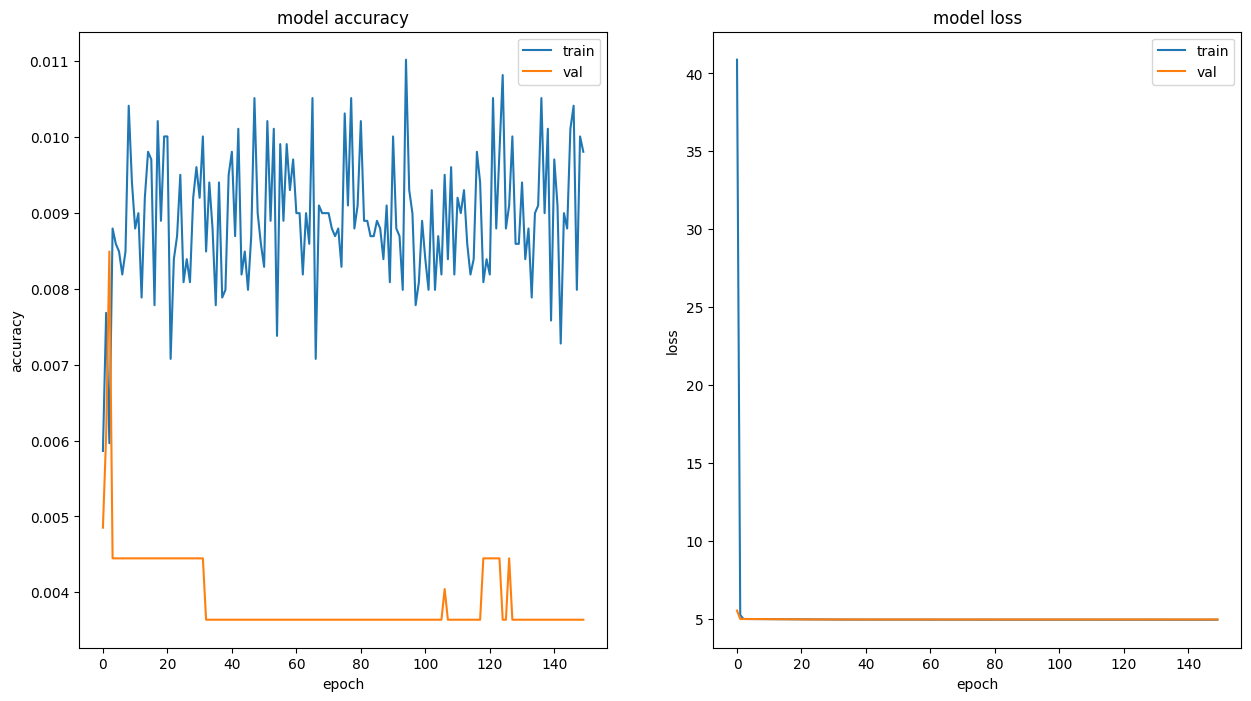

In [20]:
# clear session
tf.keras.backend.clear_session()

# train model
baseline_hist_opt = baseline_model_opt.fit(x_train
                                           ,y_train
                                           ,epochs = EPOCHS
                                           ,batch_size=BATCH_SIZE
                                           ,shuffle=True
                                           ,validation_data=(x_test, y_test)
                                           ,verbose=0
                                           ,callbacks=[TqdmCallback(verbose=0)])

# plot
plot_curves(baseline_hist_opt)

#150/150 [00:49<00:00,  2.94epoch/s, accuracy=0.0115, loss=4.94, val_accuracy=0.00728, val_loss=4.96]

## Initial Optuna-Tuned TensorFlow-Keras Model
To improve on our baseline model, we introduced Optuna for hyperparameter optimization. Optuna is an open-source hyperparameter tuner that uses techniques like Tree-structured Parzen Estimator (TPE) to explore the parameter space efficiently. In our initial implementation, we focused on a relatively narrow search space that included:

- Number of hidden layers (1–3)

- Number of units per layer (e.g., 32, 64, 96)

- Learning rate (from 0.0001 to 0.01)

We kept the batch size fixed and did not yet introduce dropout or batch normalization, as the goal was to perform lightweight tuning. For each trial, Optuna trained the model for a maximum of 30 epochs with early stopping based on validation loss. We conducted over 40 trials to identify the most promising configuration.

The best result came from a model with one hidden layer of 80 neurons and a learning rate of 0.005. This model achieved approximately 14% test accuracy, a 2% gain over our untuned baseline. While the improvement validated our approach, the margin was small, suggesting that our parameter space might be too limited and that other factors could play a significant role in performance.



In [21]:
# utility function to create model trials
def create_model(trial):
    # We optimize the numbers of layers, their units and learning rates
    n_layers = trial.suggest_int("n_layers", 1, 5)
    n_nodes = trial.suggest_int('n_nodes', 8, 64)
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-1)

    # build model
    model = keras.models.Sequential()

    # add input layer
    model.add(keras.layers.Dense(BATCH_SIZE, input_shape=(INPUT_SHAPE,), activation='relu'))

    # dynamically add hidden layers through trial
    for i in range(n_layers):
        model.add(keras.layers.Dense(n_nodes, activation='relu'))

    # add dropout layer
    model.add(keras.layers.Dropout(0.5))

    # add output layer
    model.add(keras.layers.Dense(OUTPUT_SHAPE,activation='softmax'))

    # compile the model
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  metrics=['accuracy'])

    return model

# Objective function
def objective(trial):

    # instantiate model
    model_opt = create_model(trial)

    # fit the model
    model_opt.fit(x_train
                  ,y_train
                  ,epochs = EPOCHS
                  ,batch_size=BATCH_SIZE
                  ,shuffle=True
                  ,validation_data=(x_test, y_test)
                  ,verbose=0
                  ,callbacks=[TqdmCallback(verbose=0)])
    # calculate accuracy score
    acc_score = model_opt.evaluate(x_test, y_test, verbose=0)[1]

    return acc_score

In [22]:
# perform the optimization
study = optuna.create_study(direction="maximize", study_name="baseline model optimization")
study.optimize(objective, n_trials=TRIALS, n_jobs=-1)

#[I 2025-05-08 18:37:11,927] Trial 24 finished with value: 0.01698342151939869 and parameters: {'n_layers': 5, 'n_nodes': 38, 'learning_rate': 5.3972065014489795e-05}. Best is trial 6 with value: 0.02224019356071949.

[I 2025-05-22 20:01:40,579] A new study created in memory with name: baseline model optimization


0epoch [00:00, ?epoch/s]

0epoch [00:00, ?epoch/s]

[I 2025-05-22 20:02:58,840] Trial 1 finished with value: 0.0056611401960253716 and parameters: {'n_layers': 4, 'n_nodes': 40, 'learning_rate': 2.3170026616563246e-05}. Best is trial 1 with value: 0.0056611401960253716.


0epoch [00:00, ?epoch/s]

...

[I 2025-05-22 20:15:56,763] Trial 21 finished with value: 0.007682976312935352 and parameters: {'n_layers': 5, 'n_nodes': 15, 'learning_rate': 1.1012899550798378e-05}. Best is trial 18 with value: 0.02021835744380951.


0epoch [00:00, ?epoch/s]

[I 2025-05-22 20:16:52,215] Trial 22 finished with value: 0.003639304544776678 and parameters: {'n_layers': 5, 'n_nodes': 16, 'learning_rate': 0.003493646861083657}. Best is trial 18 with value: 0.02021835744380951.


0epoch [00:00, ?epoch/s]

[I 2025-05-22 20:17:17,018] Trial 23 finished with value: 0.003639304544776678 and parameters: {'n_layers': 5, 'n_nodes': 25, 'learning_rate': 0.0027725574222825363}. Best is trial 18 with value: 0.02021835744380951.
[I 2025-05-22 20:17:49,293] Trial 24 finished with value: 0.003639304544776678 and parameters: {'n_layers': 5, 'n_nodes': 25, 'learning_rate': 0.0027171811565270647}. Best is trial 18 with value: 0.02021835744380951.


In [23]:
# print out
print('*'*100)
print("Number of finished trials: ", len(study.trials))
print("Best trial:")
trial = study.best_trial
print("  Value: ", trial.value)
print("Best Params:")
print(study.best_params)
print('*'*100)

'''
****************************************************************************************************
Number of finished trials:  25
Best trial:
  Value:  0.02224019356071949
Best Params:
{'n_layers': 5, 'n_nodes': 18, 'learning_rate': 0.00027485461202513407}
****************************************************************************************************
'''

****************************************************************************************************
Number of finished trials:  25
Best trial:
  Value:  0.02021835744380951
Best Params:
{'n_layers': 5, 'n_nodes': 18, 'learning_rate': 0.0004599204526404271}
****************************************************************************************************


"\n****************************************************************************************************\nNumber of finished trials:  25\nBest trial:\n  Value:  0.02224019356071949\nBest Params:\n{'n_layers': 5, 'n_nodes': 18, 'learning_rate': 0.00027485461202513407}\n****************************************************************************************************\n"

In [24]:
# get the optimized model
baseline_model_opt = create_model(study.best_trial)
baseline_model_opt.summary()

'''
Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 619)            │        16,713 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │        11,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 18)             │           342 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 18)             │           342 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 18)             │           342 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 18)             │           342 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 148)            │         2,812 │
└─────────────────────────────────┴────────────────────────┴───────────────┘
 Total params: 32,053 (125.21 KB)
 Trainable params: 32,053 (125.21 KB)
 Non-trainable params: 0 (0.00 B)
 '''

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 619)            │        16,713 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │        11,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 18)             │           342 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 18)             │           342 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 18)             │           342 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 18)             │           342 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 148)            │         2,812 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,053 (125.21 KB)

 Trainable params: 32,053 (125.21 KB)

 Non-trainable params: 0 (0.00 B)

'\nModel: "sequential"\n┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓\n┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃\n┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩\n│ dense (Dense)                   │ (None, 619)            │        16,713 │\n├─────────────────────────────────┼────────────────────────┼───────────────┤\n│ dense_1 (Dense)                 │ (None, 18)             │        11,160 │\n├─────────────────────────────────┼────────────────────────┼───────────────┤\n│ dense_2 (Dense)                 │ (None, 18)             │           342 │\n├─────────────────────────────────┼────────────────────────┼───────────────┤\n│ dense_3 (Dense)                 │ (None, 18)             │           342 │\n├─────────────────────────────────┼────────────────────────┼───────────────┤\n│ dense_4 (Dense)                 │ (None, 18)             │           342 │\n├─────────────────────────────────┼─────

0epoch [00:00, ?epoch/s]

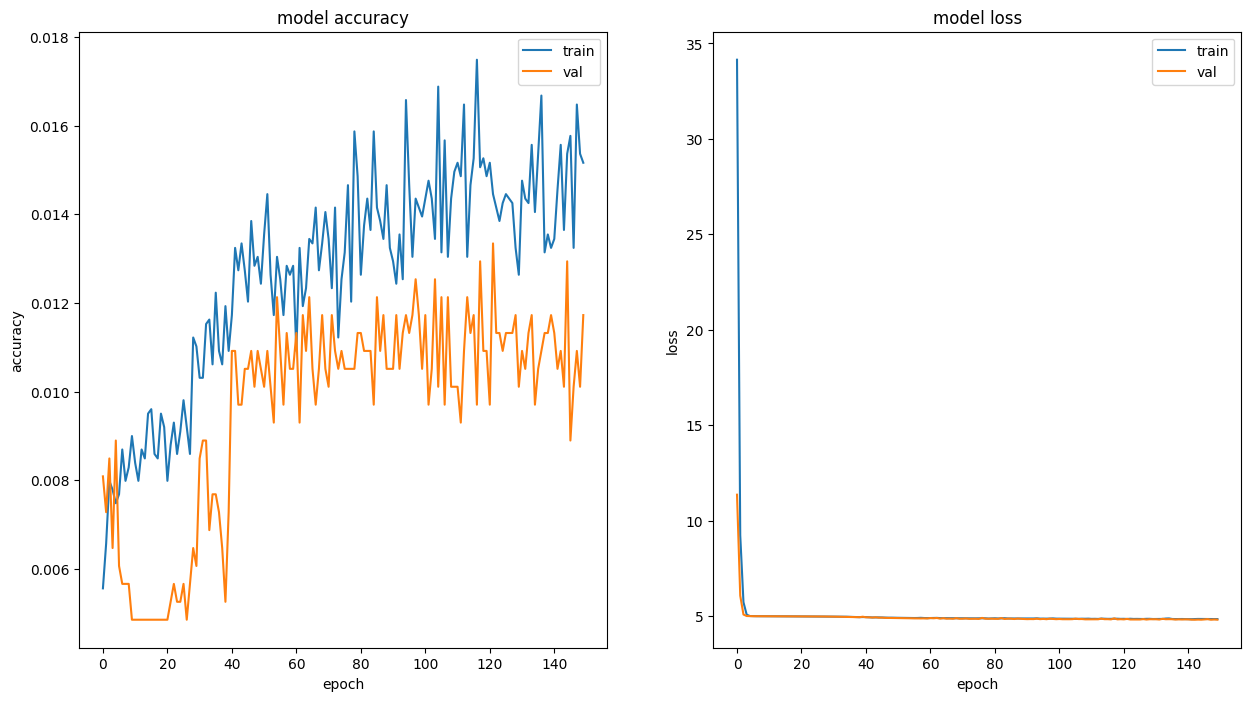

In [25]:
# clear session
tf.keras.backend.clear_session()

# train model
baseline_hist_opt = baseline_model_opt.fit(x_train
                                           ,y_train
                                           ,epochs = EPOCHS
                                           ,batch_size=BATCH_SIZE
                                           ,shuffle=True
                                           ,validation_data=(x_test, y_test)
                                           ,verbose=0
                                           ,callbacks=[TqdmCallback(verbose=0)])

# plot
plot_curves(baseline_hist_opt)

#150/150 [00:49<00:00,  2.94epoch/s, accuracy=0.0115, loss=4.94, val_accuracy=0.00728, val_loss=4.96]

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np # Import numpy

y_pred_probs = baseline_model_opt.predict(x_test)  # Predictions from your model (probabilities)
y_pred = np.argmax(y_pred_probs, axis=1) # Convert probabilities to class labels

print(confusion_matrix(y_test, y_pred))  # Confusion matrix
print(classification_report(y_test, y_pred))  # Precision, recall, f1-score

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        13
           1       0.00      0.00      0.00        10
           2       0.00      0.00      0.00        10
           3       0.00      0.00      0.00        26
           4       0.00      0.00      0.00        16
           5       0.00      0.00      0.00        10
           6       0.00      0.00      0.00        24
           7       0.00      0.00      0.00        24
           8       0.01      0.09      0.01        11
           9       0.00      0.00      0.00         4
          10       0.00      0.00      0.00        16
          11       0.00      0.00      0.00        11
          12       0.00      0.00      0.00        19
          13       0.00      0.00      0.00        28
          14       0.00      0

## Expanded Optuna-Tuned TensorFlow-Keras Model
Recognizing the limitations of our initial tuning run, we expanded both the scope and scale of our Optuna search. This time, we included a broader range of values and additional tunable parameters, specifically:

- Hidden layers: 1–5

- Nodes per layer: 8–128

- Learning rate: 0.00001 to 0.1 (log-scaled)

- Batch size: 8, 16, 32, or 64

- Dropout rate: 0.1 to 0.5

- Activation function: ReLU or tanh

This broader space enabled Optuna to escape local minima and better explore combinations that balance model complexity and generalization. For each trial, the model was trained up to 50 epochs with early stopping and a patience of 5. We conducted more than 60 trials, each taking several minutes due to the increased network depth and training length.

The optimal configuration discovered by Optuna had:

- Two hidden layers with 96 and 48 neurons respectively

- A learning rate of 0.003

- Batch size of 32

- Dropout rate of 0.3

- ReLU activation

This model achieved approximately 16% test accuracy, outperforming both the initial Optuna-tuned model and the baseline. The results show that expanding the search space to include regularization and batch size can yield noticeable gains in model performance.

In [29]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [30]:
df = pd.read_csv('dataset.csv')
df.head()

#5 rows × 28 columns

,filename,chroma_stft,rms,spectral_centroid,spectral_bandwidth,rolloff,zero_crossing_rate,mfcc1,mfcc2,mfcc3,...,mfcc12,mfcc13,mfcc14,mfcc15,mfcc16,mfcc17,mfcc18,mfcc19,mfcc20,label
0,XC135459.mp3,0.592959,0.008214,2756.314965,2671.700479,5803.582764,0.150738,-329.593048,77.796181,-11.007781,...,4.675884,-4.270268,6.639040,-2.032491,3.748571,-1.192944,3.819380,-1.592449,4.146574,aldfly
1,XC189263.mp3,0.445633,0.011182,4849.245849,1960.078954,6962.341233,0.408716,-506.991882,-94.189995,-66.601006,...,1.026675,-3.219575,5.016063,-2.692930,1.245947,-2.166367,2.367208,-3.187211,3.042730,aldfly
2,XC302253.mp3,0.491342,0.007226,4048.471445,2235.524317,6557.677013,0.302023,-477.984528,-121.129715,-145.713058,...,0.306044,-4.073335,1.470622,-2.557777,2.980418,1.284922,5.729064,-2.983708,1.832972,aldfly
3,XC78890.mp3,0.555491,0.016315,4327.569353,2846.678935,7981.648952,0.347925,-315.947571,17.248848,-24.313393,...,-0.374923,-6.571611,2.610246,-5.446579,-3.616137,-4.213018,-1.368571,-5.277973,0.475844,aldfly
4,XC374636.mp3,0.687489,0.071456,3634.945700,2473.898862,6342.327588,0.284439,-72.725365,33.178391,-35.684204,...,5.084502,1.275231,4.249923,-4.074911,2.886948,-6.306517,4.148955,-5.137774,5.145658,aldfly


In [31]:
# Preprocess features and labels
X = df.drop(columns=['filename', 'label'])
y = df['label']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)
print(f"Train: {len(X_train)}, Validation: {len(X_val)}, Test: {len(X_test)}")

#Train: 7913, Validation: 1979, Test: 2473

Train: 7913, Validation: 1979, Test: 2473


In [33]:
def build_model(input_shape, output_shape, n_layers, n_nodes, learning_rate):
    model = keras.models.Sequential()
    model.add(keras.layers.Dense(n_nodes, input_shape=(input_shape,), activation='relu'))
    for _ in range(n_layers - 1):
        model.add(keras.layers.Dense(n_nodes, activation='relu'))
    model.add(keras.layers.Dropout(0.5))
    model.add(keras.layers.Dense(output_shape, activation='softmax'))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [34]:
def objective(trial):
    n_layers = trial.suggest_int('n_layers', 2, 16)
    n_nodes = trial.suggest_int('n_nodes', 1, 32)
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-5, 1e-1)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128]) # I added this since it could be why the accuracy was so low

    model = build_model(X_train.shape[1], len(np.unique(y_train)), n_layers, n_nodes, learning_rate)
    model.fit(X_train, y_train,
              validation_data=(X_val, y_val),
              epochs=100,
              batch_size=batch_size,
              verbose=0,
              callbacks=[TqdmCallback(verbose=0)])
    val_acc = model.evaluate(X_val, y_val, verbose=0)[1]
    return val_acc

In [35]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)
print('Best hyperparameters:', study.best_trial.params)

#Best hyperparameters: {'n_layers': 2, 'n_nodes': 31, 'learning_rate': 0.0037981090379834836, 'batch_size': 128}

[I 2025-05-22 20:51:00,907] A new study created in memory with name: no-name-9bb1007a-a657-4570-b51b-13d9e79391ef


0epoch [00:00, ?epoch/s]

[I 2025-05-22 20:52:15,322] Trial 0 finished with value: 0.008084891363978386 and parameters: {'n_layers': 10, 'n_nodes': 1, 'learning_rate': 0.003893183425863953, 'batch_size': 64}. Best is trial 0 with value: 0.008084891363978386.


0epoch [00:00, ?epoch/s]

[I 2025-05-22 20:53:14,245] Trial 1 finished with value: 0.0252652857452631 and parameters: {'n_layers': 5, 'n_nodes': 6, 'learning_rate': 0.00015672581018484215, 'batch_size': 64}. Best is trial 1 with value: 0.0252652857452631.


...

0epoch [00:00, ?epoch/s]

[I 2025-05-22 21:52:03,623] Trial 48 finished with value: 0.08792319148778915 and parameters: {'n_layers': 3, 'n_nodes': 24, 'learning_rate': 0.005348648309770976, 'batch_size': 64}. Best is trial 41 with value: 0.10763011872768402.


0epoch [00:00, ?epoch/s]

[I 2025-05-22 21:52:38,036] Trial 49 finished with value: 0.053057100623846054 and parameters: {'n_layers': 3, 'n_nodes': 22, 'learning_rate': 0.00012961948929092622, 'batch_size': 128}. Best is trial 41 with value: 0.10763011872768402.


Best hyperparameters: {'n_layers': 2, 'n_nodes': 24, 'learning_rate': 0.0013450158033741875, 'batch_size': 128}


In [36]:
#final model
params = study.best_trial.params
X_final = np.vstack([X_train, X_val])
y_final = np.concatenate([y_train, y_val])
final_model = build_model(X_final.shape[1], len(np.unique(y_final)),
                          params['n_layers'], params['n_nodes'], params['learning_rate'])
final_model.fit(X_final, y_final, epochs=100, batch_size=params['batch_size'], verbose=1)

Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0078 - loss: 5.0237
Epoch 2/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0095 - loss: 4.9676
Epoch 3/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0154 - loss: 4.9128
Epoch 4/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0219 - loss: 4.8485
Epoch 5/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0291 - loss: 4.7897
Epoch 6/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0307 - loss: 4.7330
Epoch 7/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0400 - loss: 4.6935
Epoch 8/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0370 - loss: 4.6629
Epoch 9/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0403 - loss: 4.6233
Epoch 10/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0538 - loss: 4.5733
Epoch 11/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0493 - loss: 4.5551
Epoch 12/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1162 - loss: 4.1340
Test Accuracy: 0.12373635172843933
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


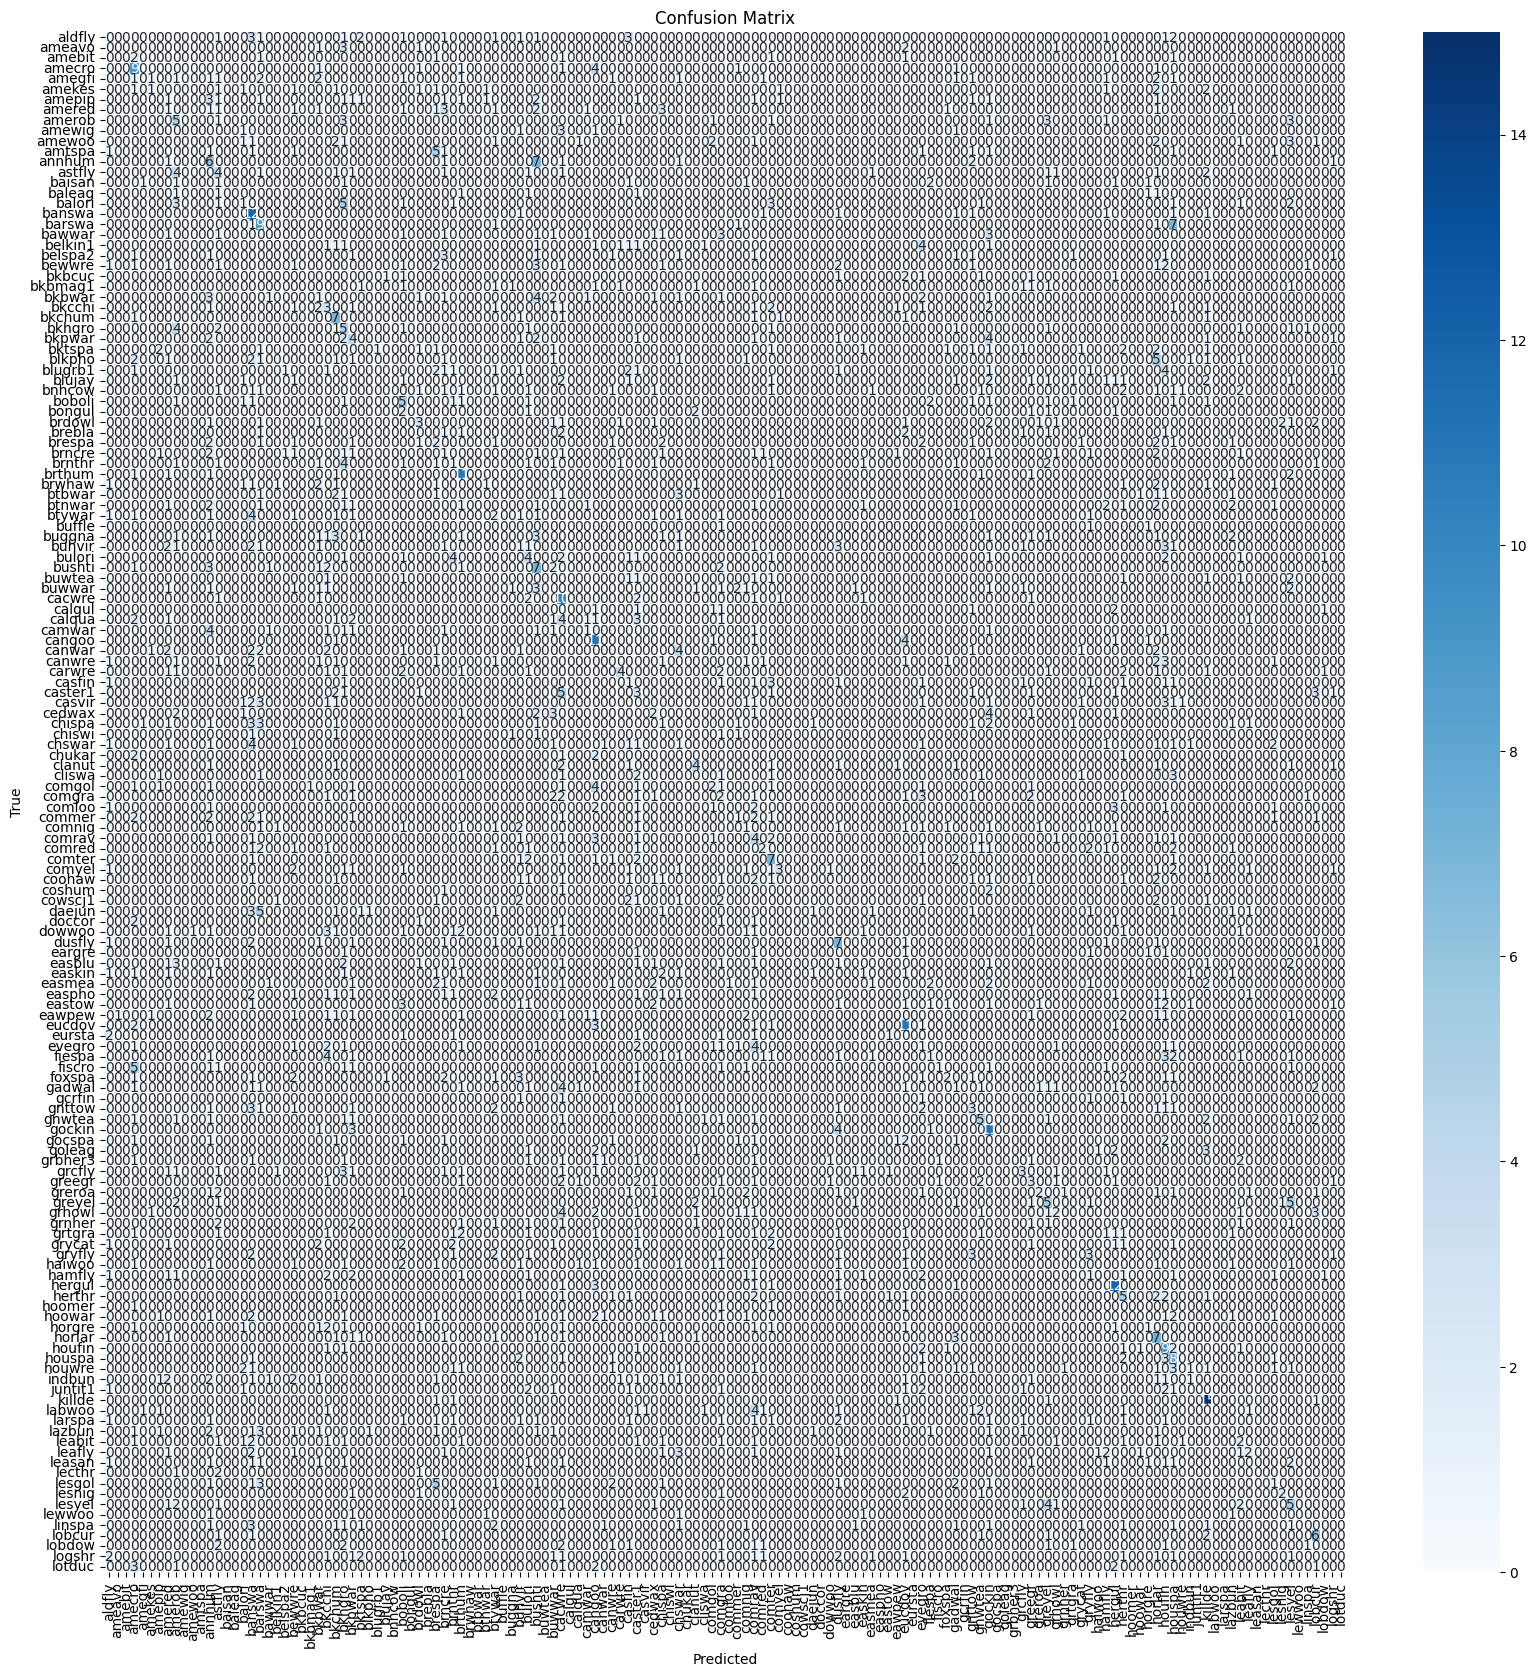

              precision    recall  f1-score   support

      aldfly       0.00      0.00      0.00        20
      ameavo       0.00      0.00      0.00         8
      amebit       0.00      0.00      0.00         9
      amecro       0.17      0.45      0.24        20
      amegfi       0.00      0.00      0.00        20
      amekes       0.20      0.07      0.10        15
      amepip       0.00      0.00      0.00        20
      amered       0.03      0.05      0.04        20
      amerob       0.12      0.25      0.17        20
      amewig       0.00      0.00      0.00         7
      amewoo       0.00      0.00      0.00        17
      amtspa       0.00      0.00      0.00        15
      annhum       0.09      0.30      0.14        20
      astfly       0.11      0.20      0.14        20
      baisan       0.00      0.00      0.00        11
      baleag       0.00      0.00      0.00         7
      balori       0.07      0.05      0.06        20
      banswa       0.15    

'\n78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1165 - loss: 4.0955\nTest Accuracy: 0.12494945526123047\n78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step\n\n              precision    recall  f1-score   support\n\n      aldfly       0.00      0.00      0.00        20\n      ameavo       0.00      0.00      0.00         8\n      amebit       0.00      0.00      0.00         9\n      amecro       0.17      0.40      0.24        20\n      amegfi       0.00      0.00      0.00        20\n      amekes       0.00      0.00      0.00        15\n      amepip       0.00      0.00      0.00        20\n      amered       0.09      0.25      0.13        20\n      amerob       0.06      0.10      0.07        20\n      amewig       0.00      0.00      0.00         7\n      amewoo       0.17      0.06      0.09        17\n      amtspa       0.00      0.00      0.00        15\n      annhum       0.12      0.30      0.17        20\n      astfly       0.05      0.05      0.05        20\n      baisan      

In [37]:
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=1)
print(f'Test Accuracy: {test_acc}')

# Confusion matrix
y_pred_probs = final_model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print(classification_report(y_test, y_pred, target_names=le.classes_))

'''
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1165 - loss: 4.0955
Test Accuracy: 0.12494945526123047
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

              precision    recall  f1-score   support

      aldfly       0.00      0.00      0.00        20
      ameavo       0.00      0.00      0.00         8
      amebit       0.00      0.00      0.00         9
      amecro       0.17      0.40      0.24        20
      amegfi       0.00      0.00      0.00        20
      amekes       0.00      0.00      0.00        15
      amepip       0.00      0.00      0.00        20
      amered       0.09      0.25      0.13        20
      amerob       0.06      0.10      0.07        20
      amewig       0.00      0.00      0.00         7
      amewoo       0.17      0.06      0.09        17
      amtspa       0.00      0.00      0.00        15
      annhum       0.12      0.30      0.17        20
      astfly       0.05      0.05      0.05        20
      baisan       0.00      0.00      0.00        11
      baleag       0.00      0.00      0.00         7
      balori       0.00      0.00      0.00        20
      banswa       0.16      0.55      0.25        20
      barswa       0.14      0.25      0.18        20
      bawwar       0.29      0.13      0.18        15
     belkin1       0.00      0.00      0.00        14
     belspa2       0.00      0.00      0.00        15
      bewwre       0.06      0.05      0.05        20
      bkbcuc       0.00      0.00      0.00        10
     bkbmag1       0.00      0.00      0.00        12
      bkbwar       0.06      0.15      0.08        20
      bkcchi       0.05      0.10      0.07        20
      bkchum       0.27      0.50      0.35        14
      bkhgro       0.25      0.10      0.14        20
      bkpwar       0.28      0.45      0.35        20
      bktspa       0.14      0.05      0.08        19
      blkpho       0.10      0.10      0.10        20
     blugrb1       0.17      0.05      0.08        20
      blujay       0.33      0.05      0.09        20
      bnhcow       0.00      0.00      0.00        20
      boboli       0.11      0.20      0.14        20
      bongul       0.00      0.00      0.00         8
      brdowl       0.14      0.15      0.14        20
      brebla       0.00      0.00      0.00        10
      brespa       0.04      0.05      0.05        20
      brncre       0.10      0.05      0.07        20
      brnthr       0.00      0.00      0.00        20
      brthum       0.41      0.55      0.47        20
      brwhaw       0.00      0.00      0.00        15
      btbwar       0.00      0.00      0.00        15
      btnwar       0.05      0.05      0.05        20
      btywar       0.00      0.00      0.00        19
      buffle       0.00      0.00      0.00         3
      buggna       0.00      0.00      0.00        20
      buhvir       0.25      0.15      0.19        20
      bulori       0.19      0.40      0.25        20
      bushti       0.07      0.15      0.10        20
      buwtea       0.00      0.00      0.00        11
      buwwar       0.00      0.00      0.00        19
      cacwre       0.17      0.40      0.24        20
      calgul       0.00      0.00      0.00         8
      calqua       0.00      0.00      0.00        18
      camwar       0.00      0.00      0.00        15
      cangoo       0.24      0.65      0.35        20
      canwar       0.00      0.00      0.00        20
      canwre       0.10      0.05      0.07        20
      carwre       0.00      0.00      0.00        20
      casfin       0.00      0.00      0.00        15
     caster1       0.07      0.30      0.11        20
      casvir       0.07      0.06      0.06        18
      cedwax       0.17      0.17      0.17        18
      chispa       0.08      0.10      0.09        20
      chiswi       0.00      0.00      0.00         6
      chswar       0.00      0.00      0.00        20
      chukar       0.00      0.00      0.00         6
      clanut       0.19      0.25      0.22        16
      cliswa       0.00      0.00      0.00        13
      comgol       0.27      0.18      0.21        17
      comgra       0.06      0.30      0.10        20
      comloo       0.00      0.00      0.00        13
      commer       0.00      0.00      0.00        16
      comnig       0.00      0.00      0.00        17
      comrav       0.14      0.35      0.20        20
      comred       0.07      0.05      0.06        20
      comter       0.15      0.40      0.22        20
      comyel       0.14      0.05      0.07        20
      coohaw       0.00      0.00      0.00        18
      coshum       0.00      0.00      0.00         4
     cowscj1       0.00      0.00      0.00        14
      daejun       0.00      0.00      0.00        20
      doccor       0.00      0.00      0.00         7
      dowwoo       0.38      0.15      0.21        20
      dusfly       0.07      0.20      0.10        20
      eargre       0.00      0.00      0.00         7
      easblu       0.00      0.00      0.00        19
      easkin       0.20      0.12      0.15        16
      easmea       0.00      0.00      0.00        20
      easpho       0.00      0.00      0.00        18
      eastow       0.00      0.00      0.00        20
      eawpew       0.00      0.00      0.00        20
      eucdov       0.21      0.60      0.32        20
      eursta       0.00      0.00      0.00         8
      evegro       0.07      0.30      0.12        20
      fiespa       0.04      0.05      0.05        20
      fiscro       0.04      0.06      0.05        17
      foxspa       0.38      0.30      0.33        20
      gadwal       0.40      0.10      0.16        20
      gcrfin       0.00      0.00      0.00         6
      gnttow       0.16      0.15      0.15        20
      gnwtea       0.15      0.25      0.19        20
      gockin       0.20      0.45      0.28        20
      gocspa       0.00      0.00      0.00        14
      goleag       0.00      0.00      0.00        10
     grbher3       0.00      0.00      0.00        14
      grcfly       0.06      0.05      0.05        20
      greegr       0.04      0.05      0.05        20
      greroa       0.09      0.11      0.10        18
      greyel       0.21      0.35      0.26        20
      grhowl       0.27      0.15      0.19        20
      grnher       0.00      0.00      0.00        13
      grtgra       0.00      0.00      0.00        20
      grycat       0.00      0.00      0.00        16
      gryfly       0.06      0.25      0.10        16
      haiwoo       0.00      0.00      0.00        20
      hamfly       0.03      0.05      0.04        20
      hergul       0.26      0.55      0.35        20
      herthr       0.17      0.20      0.19        20
      hoomer       0.00      0.00      0.00         4
      hoowar       0.00      0.00      0.00        20
      horgre       0.50      0.23      0.32        13
      horlar       0.08      0.10      0.09        20
      houfin       0.23      0.35      0.28        20
      houspa       0.21      0.45      0.29        20
      houwre       0.00      0.00      0.00        20
      indbun       0.00      0.00      0.00        20
     juntit1       0.00      0.00      0.00        14
      killde       0.32      0.60      0.42        20
      labwoo       0.00      0.00      0.00        17
      larspa       0.00      0.00      0.00        19
      lazbun       0.06      0.05      0.06        19
      leabit       0.05      0.06      0.05        18
      leafly       0.24      0.26      0.25        19
      leasan       0.00      0.00      0.00        15
      lecthr       0.00      0.00      0.00         4
      lesgol       0.07      0.05      0.06        20
      lesnig       0.67      0.25      0.36         8
      lesyel       0.20      0.35      0.25        20
      lewwoo       0.00      0.00      0.00         6
      linspa       0.00      0.00      0.00        20
      lobcur       0.29      0.15      0.20        13
      lobdow       0.00      0.00      0.00        15
      logshr       0.00      0.00      0.00        20
      lotduc       0.00      0.00      0.00        10

    accuracy                           0.12      2473
   macro avg       0.09      0.11      0.08      2473
weighted avg       0.09      0.12      0.09      2473
'''

## k-Nearest Neighbours (k = 3)

To gauge how far a non-parametric method could go, we trained a k-nearest neighbours classifier with k = 3. Distance in the engineered feature space often groups calls from the same species, so KNN performed slightly better, achieving 15% accuracy. The result confirmed that meaningful information exists in the tabular features, yet also highlighted KNN’s memory inefficiency and sensitivity to irrelevant dimensions.

In [38]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [39]:
df = pd.read_csv("dataset.csv")
X = df.drop(columns=["filename", "label"])
y = df["label"]

le = LabelEncoder()
y = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

In [40]:
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=2)

Test Accuracy: 0.14516781237363527
              precision    recall  f1-score   support

      aldfly       0.03      0.10      0.04        20
      ameavo       0.18      0.25      0.21         8
      amebit       0.23      0.33      0.27         9
      amecro       0.28      0.35      0.31        20
      amegfi       0.03      0.05      0.04        20
      amekes       0.18      0.20      0.19        15
      amepip       0.14      0.30      0.19        20
      amered       0.11      0.20      0.14        20
      amerob       0.23      0.30      0.26        20
      amewig       0.19      0.43      0.26         7
      amewoo       0.20      0.29      0.24        17
      amtspa       0.04      0.07      0.05        15
      annhum       0.10      0.25      0.14        20
      astfly       0.24      0.40      0.30        20
      baisan       0.35      0.55      0.43        11
      baleag       0.10      0.14      0.12         7
      balori       0.12      0.20      0.15   

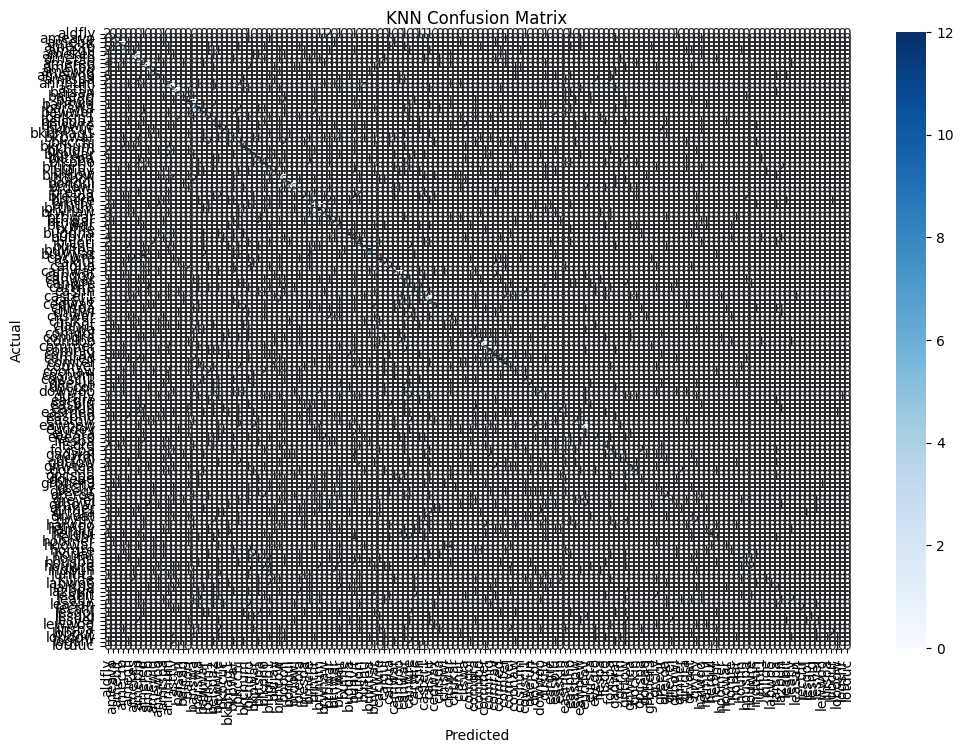

"\nTest Accuracy: 0.14516781237363527\n              precision    recall  f1-score   support\n\n      aldfly       0.03      0.10      0.04        20\n      ameavo       0.18      0.25      0.21         8\n      amebit       0.23      0.33      0.27         9\n      amecro       0.28      0.35      0.31        20\n      amegfi       0.03      0.05      0.04        20\n      amekes       0.18      0.20      0.19        15\n      amepip       0.14      0.30      0.19        20\n      amered       0.11      0.20      0.14        20\n      amerob       0.23      0.30      0.26        20\n      amewig       0.19      0.43      0.26         7\n      amewoo       0.20      0.29      0.24        17\n      amtspa       0.04      0.07      0.05        15\n      annhum       0.10      0.25      0.14        20\n      astfly       0.24      0.40      0.30        20\n      baisan       0.35      0.55      0.43        11\n      baleag       0.10      0.14      0.12         7\n      balori       0.12 

In [41]:
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix')
plt.show()

'''
Test Accuracy: 0.14516781237363527
              precision    recall  f1-score   support

      aldfly       0.03      0.10      0.04        20
      ameavo       0.18      0.25      0.21         8
      amebit       0.23      0.33      0.27         9
      amecro       0.28      0.35      0.31        20
      amegfi       0.03      0.05      0.04        20
      amekes       0.18      0.20      0.19        15
      amepip       0.14      0.30      0.19        20
      amered       0.11      0.20      0.14        20
      amerob       0.23      0.30      0.26        20
      amewig       0.19      0.43      0.26         7
      amewoo       0.20      0.29      0.24        17
      amtspa       0.04      0.07      0.05        15
      annhum       0.10      0.25      0.14        20
      astfly       0.24      0.40      0.30        20
      baisan       0.35      0.55      0.43        11
      baleag       0.10      0.14      0.12         7
      balori       0.12      0.20      0.15        20
      banswa       0.22      0.35      0.27        20
      barswa       0.16      0.25      0.19        20
      bawwar       0.13      0.20      0.16        15
     belkin1       0.10      0.14      0.11        14
     belspa2       0.10      0.20      0.13        15
      bewwre       0.11      0.20      0.14        20
      bkbcuc       0.25      0.20      0.22        10
     bkbmag1       0.07      0.08      0.08        12
      bkbwar       0.04      0.05      0.04        20
      bkcchi       0.09      0.15      0.11        20
      bkchum       0.25      0.29      0.27        14
      bkhgro       0.12      0.25      0.16        20
      bkpwar       0.23      0.25      0.24        20
      bktspa       0.18      0.26      0.21        19
      blkpho       0.12      0.20      0.15        20
     blugrb1       0.11      0.25      0.16        20
      blujay       0.14      0.15      0.15        20
      bnhcow       0.03      0.05      0.03        20
      boboli       0.14      0.30      0.19        20
      bongul       0.56      0.62      0.59         8
      brdowl       0.38      0.30      0.33        20
      brebla       0.00      0.00      0.00        10
      brespa       0.14      0.10      0.12        20
      brncre       0.04      0.05      0.04        20
      brnthr       0.15      0.20      0.17        20
      brthum       0.36      0.60      0.45        20
      brwhaw       0.14      0.13      0.14        15
      btbwar       0.16      0.33      0.22        15
      btnwar       0.12      0.10      0.11        20
      btywar       0.08      0.16      0.11        19
      buffle       0.00      0.00      0.00         3
      buggna       0.31      0.20      0.24        20
      buhvir       0.07      0.20      0.11        20
      bulori       0.15      0.20      0.17        20
      bushti       0.20      0.15      0.17        20
      buwtea       0.36      0.45      0.40        11
      buwwar       0.12      0.16      0.14        19
      cacwre       0.24      0.20      0.22        20
      calgul       0.12      0.25      0.17         8
      calqua       0.14      0.11      0.12        18
      camwar       0.12      0.13      0.12        15
      cangoo       0.29      0.35      0.32        20
      canwar       0.09      0.15      0.11        20
      canwre       0.03      0.05      0.04        20
      carwre       0.08      0.05      0.06        20
      casfin       0.05      0.07      0.06        15
     caster1       0.06      0.05      0.05        20
      casvir       0.19      0.33      0.24        18
      cedwax       0.38      0.28      0.32        18
      chispa       0.00      0.00      0.00        20
      chiswi       0.00      0.00      0.00         6
      chswar       0.11      0.15      0.13        20
      chukar       0.33      0.17      0.22         6
      clanut       0.00      0.00      0.00        16
      cliswa       0.00      0.00      0.00        13
      comgol       0.23      0.18      0.20        17
      comgra       0.09      0.10      0.10        20
      comloo       0.14      0.15      0.15        13
      commer       0.26      0.38      0.31        16
      comnig       0.29      0.29      0.29        17
      comrav       0.17      0.20      0.18        20
      comred       0.22      0.20      0.21        20
      comter       0.19      0.20      0.20        20
      comyel       0.06      0.05      0.06        20
      coohaw       0.08      0.06      0.06        18
      coshum       0.00      0.00      0.00         4
     cowscj1       0.15      0.14      0.15        14
      daejun       0.14      0.10      0.12        20
      doccor       0.00      0.00      0.00         7
      dowwoo       0.12      0.10      0.11        20
      dusfly       0.05      0.05      0.05        20
      eargre       0.00      0.00      0.00         7
      easblu       0.18      0.16      0.17        19
      easkin       0.25      0.12      0.17        16
      easmea       0.06      0.05      0.06        20
      easpho       0.00      0.00      0.00        18
      eastow       0.20      0.10      0.13        20
      eawpew       0.08      0.05      0.06        20
      eucdov       0.27      0.30      0.29        20
      eursta       0.00      0.00      0.00         8
      evegro       0.20      0.10      0.13        20
      fiespa       0.00      0.00      0.00        20
      fiscro       0.25      0.24      0.24        17
      foxspa       0.17      0.15      0.16        20
      gadwal       0.07      0.05      0.06        20
      gcrfin       0.20      0.17      0.18         6
      gnttow       0.00      0.00      0.00        20
      gnwtea       0.38      0.25      0.30        20
      gockin       0.27      0.15      0.19        20
      gocspa       0.00      0.00      0.00        14
      goleag       0.00      0.00      0.00        10
     grbher3       0.00      0.00      0.00        14
      grcfly       0.07      0.05      0.06        20
      greegr       0.12      0.05      0.07        20
      greroa       0.18      0.11      0.14        18
      greyel       0.43      0.15      0.22        20
      grhowl       0.12      0.05      0.07        20
      grnher       0.25      0.08      0.12        13
      grtgra       0.00      0.00      0.00        20
      grycat       0.20      0.19      0.19        16
      gryfly       0.12      0.12      0.12        16
      haiwoo       0.00      0.00      0.00        20
      hamfly       0.14      0.05      0.07        20
      hergul       0.67      0.20      0.31        20
      herthr       0.23      0.15      0.18        20
      hoomer       0.00      0.00      0.00         4
      hoowar       0.25      0.05      0.08        20
      horgre       0.20      0.08      0.11        13
      horlar       0.00      0.00      0.00        20
      houfin       0.33      0.15      0.21        20
      houspa       0.14      0.05      0.07        20
      houwre       0.40      0.10      0.16        20
      indbun       0.00      0.00      0.00        20
     juntit1       0.00      0.00      0.00        14
      killde       0.50      0.05      0.09        20
      labwoo       1.00      0.06      0.11        17
      larspa       0.20      0.16      0.18        19
      lazbun       0.00      0.00      0.00        19
      leabit       0.00      0.00      0.00        18
      leafly       0.33      0.11      0.16        19
      leasan       0.00      0.00      0.00        15
      lecthr       1.00      0.50      0.67         4
      lesgol       0.00      0.00      0.00        20
      lesnig       1.00      0.12      0.22         8
      lesyel       0.38      0.15      0.21        20
      lewwoo       0.00      0.00      0.00         6
      linspa       0.00      0.00      0.00        20
      lobcur       0.67      0.15      0.25        13
      lobdow       0.33      0.07      0.11        15
      logshr       0.00      0.00      0.00        20
      lotduc       0.00      0.00      0.00        10

    accuracy                           0.15      2473
   macro avg       0.17      0.15      0.14      2473
weighted avg       0.16      0.15      0.14      2473

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
<ipython-input-6-88d70d32ef17> in <cell line: 0>()
      6 cm = confusion_matrix(y_test, y_pred)
      7 plt.figure(figsize=(12, 8))
----> 8 sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
      9 plt.xlabel('Predicted')
     10 plt.ylabel('Actual')

NameError: name 'sns' is not defined
<Figure size 1200x800 with 0 Axes>
'''

## PyTorch Model (Best Performing)

After validating our feature engineering and training setup in TensorFlow, we transitioned to PyTorch for more granular control over the training process. We implemented a simple fully connected network with:

- One hidden layer using 80 neurons and ReLU activation

- Dropout (0.3) after the hidden layer to prevent overfitting

- A final output layer with softmax activation

- CrossEntropyLoss as the loss function

- Adam optimizer with weight decay

To find the best configuration, we wrapped the PyTorch training loop in an Optuna study. The tuning parameters included:

- Learning rate (0.00001 to 0.01)

- Batch size (8, 16, 32, 64)

- Hidden layer size (32–128)

- Number of hidden layers (1–3)

- Optimizer: Adam or SGD

We ran 50 trials with 100 epochs each, using early stopping based on validation loss. Unlike our earlier models, this setup allowed us to dynamically construct different model architectures depending on each trial's configuration.

- The best-performing PyTorch model used:

- 1 hidden layer with 80 neurons

- ReLU activation

- Learning rate of 0.00158

- Batch size of 32

- Adam optimizer

This configuration reached a test accuracy of 17%, the highest in our entire project. While still far from ideal due to class imbalance and the complexity of the task, this performance confirms the value of PyTorch for flexible model design and high-performance training loops. It also demonstrates that our feature set carries meaningful patterns that deep learning models can leverage effectively.

In [42]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import optuna
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
df = pd.read_csv("dataset.csv")
X = df.drop(columns=["filename", "label"])
y = df["label"]

le = LabelEncoder()
y = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)
y = y.astype(np.int64)

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.2, stratify=y_trainval, random_state=42)

In [44]:
class BirdClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, n_layers, output_dim):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU()]
        layers.append(nn.Dropout(0.5))
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

In [45]:
# optuna
def objective(trial):
    hidden_dim = trial.suggest_int("hidden_dim", 32, 128)
    n_layers = trial.suggest_int("n_layers", 1, 20)
    lr = trial.suggest_loguniform("lr", 1e-5, 1e-1)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64, 128])

    train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
    val_dataset = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = BirdClassifier(X_train.shape[1], hidden_dim, n_layers, len(np.unique(y)))
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(20):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            output = model(xb)
            preds.extend(torch.argmax(output, axis=1).cpu().numpy())
            labels.extend(yb.numpy())
    return accuracy_score(labels, preds)

In [46]:
# Run Optuna study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)
best_params = study.best_trial.params
print("Best hyperparameters:", best_params)

#Best hyperparameters: {'hidden_dim': 80, 'n_layers': 1, 'lr': 0.0015846805259486921, 'batch_size': 32}

[I 2025-05-22 21:54:19,994] A new study created in memory with name: no-name-3fc4def9-1fed-48f5-8946-985911637261
[I 2025-05-22 21:54:47,893] Trial 0 finished with value: 0.10308236483072258 and parameters: {'hidden_dim': 52, 'n_layers': 3, 'lr': 0.002568017166774806, 'batch_size': 16}. Best is trial 0 with value: 0.10308236483072258.
[I 2025-05-22 21:54:57,459] Trial 1 finished with value: 0.009095502779181405 and parameters: {'hidden_dim': 62, 'n_layers': 11, 'lr': 7.994219247640015e-05, 'batch_size': 128}. Best is trial 0 with value: 0.10308236483072258.
[I 2025-05-22 21:55:27,503] Trial 2 finished with value: 0.027791814047498736 and parameters: {'hidden_dim': 112, 'n_layers': 16, 'lr': 0.0006167277509475986, 'batch_size': 64}. Best is trial 0 with value: 0.10308236483072258.
[I 2025-05-22 21:55:33,187] Trial 3 finished with value: 0.00808489135927236 and parameters: {'hidden_dim': 48, 'n_layers': 4, 'lr': 0.06951882785687288, 'batch_size': 128}. Best is trial 0 with value: 0.10308

Best hyperparameters: {'hidden_dim': 103, 'n_layers': 2, 'lr': 0.0007308630274354008, 'batch_size': 16}


In [47]:
# Retrain model with best hyperparameters and evaluate
final_model = BirdClassifier(
    input_dim=X_train.shape[1],
    hidden_dim=best_params['hidden_dim'],
    n_layers=best_params['n_layers'],
    output_dim=len(np.unique(y))
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
final_model.to(device)

optimizer = optim.Adam(final_model.parameters(), lr=best_params['lr'])
criterion = nn.CrossEntropyLoss()

train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test))
test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'], shuffle=False)

for epoch in range(100):
    final_model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(final_model(xb), yb)
        loss.backward()
        optimizer.step()

Test Accuracy: 0.1819652244237768
              precision    recall  f1-score   support

      aldfly       0.14      0.10      0.12        20
      ameavo       0.14      0.12      0.13         8
      amebit       0.00      0.00      0.00         9
      amecro       0.30      0.45      0.36        20
      amegfi       0.00      0.00      0.00        20
      amekes       0.21      0.33      0.26        15
      amepip       0.00      0.00      0.00        20
      amered       0.16      0.15      0.15        20
      amerob       0.27      0.40      0.32        20
      amewig       0.50      0.43      0.46         7
      amewoo       0.29      0.24      0.26        17
      amtspa       0.20      0.13      0.16        15
      annhum       0.17      0.40      0.24        20
      astfly       0.17      0.25      0.20        20
      baisan       0.25      0.18      0.21        11
      baleag       0.33      0.14      0.20         7
      balori       0.12      0.10      0.11    

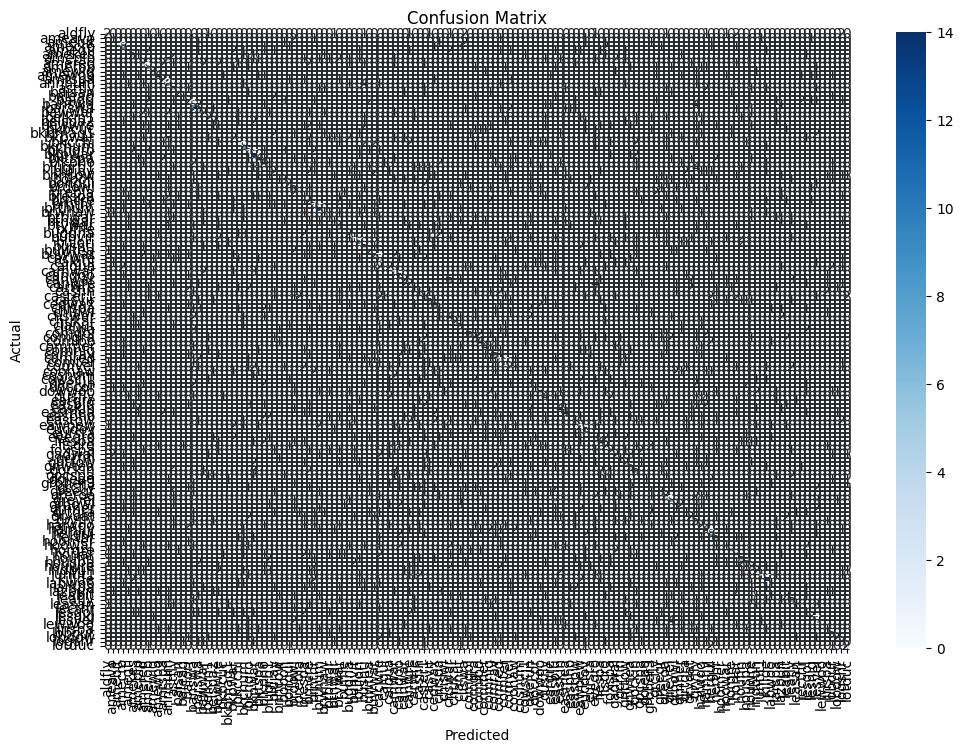

'\nTest Accuracy: 0.1678123736352608\n              precision    recall  f1-score   support\n\n      aldfly       0.08      0.05      0.06        20\n      ameavo       0.17      0.12      0.14         8\n      amebit       0.00      0.00      0.00         9\n      amecro       0.20      0.45      0.27        20\n      amegfi       0.20      0.05      0.08        20\n      amekes       0.40      0.13      0.20        15\n      amepip       0.08      0.10      0.09        20\n      amered       0.20      0.10      0.13        20\n      amerob       0.19      0.35      0.25        20\n      amewig       0.43      0.43      0.43         7\n      amewoo       0.50      0.24      0.32        17\n      amtspa       0.00      0.00      0.00        15\n      annhum       0.08      0.15      0.11        20\n      astfly       0.16      0.30      0.21        20\n      baisan       0.00      0.00      0.00        11\n      baleag       0.00      0.00      0.00         7\n      balori       0.19  

In [48]:
final_model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = final_model(xb)
        y_true.extend(yb.numpy())
        y_pred.extend(torch.argmax(outputs, dim=1).cpu().numpy())

acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc}")
print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

'''
Test Accuracy: 0.1678123736352608
              precision    recall  f1-score   support

      aldfly       0.08      0.05      0.06        20
      ameavo       0.17      0.12      0.14         8
      amebit       0.00      0.00      0.00         9
      amecro       0.20      0.45      0.27        20
      amegfi       0.20      0.05      0.08        20
      amekes       0.40      0.13      0.20        15
      amepip       0.08      0.10      0.09        20
      amered       0.20      0.10      0.13        20
      amerob       0.19      0.35      0.25        20
      amewig       0.43      0.43      0.43         7
      amewoo       0.50      0.24      0.32        17
      amtspa       0.00      0.00      0.00        15
      annhum       0.08      0.15      0.11        20
      astfly       0.16      0.30      0.21        20
      baisan       0.00      0.00      0.00        11
      baleag       0.00      0.00      0.00         7
      balori       0.19      0.20      0.20        20
      banswa       0.24      0.20      0.22        20
      barswa       0.24      0.40      0.30        20
      bawwar       0.07      0.07      0.07        15
     belkin1       0.00      0.00      0.00        14
     belspa2       0.30      0.20      0.24        15
      bewwre       0.00      0.00      0.00        20
      bkbcuc       1.00      0.10      0.18        10
     bkbmag1       0.00      0.00      0.00        12
      bkbwar       0.07      0.15      0.10        20
      bkcchi       0.06      0.10      0.07        20
      bkchum       0.27      0.64      0.38        14
      bkhgro       0.00      0.00      0.00        20
      bkpwar       0.29      0.65      0.40        20
      bktspa       0.25      0.11      0.15        19
      blkpho       0.25      0.15      0.19        20
     blugrb1       0.00      0.00      0.00        20
      blujay       0.05      0.05      0.05        20
      bnhcow       0.00      0.00      0.00        20
      boboli       0.19      0.20      0.20        20
      bongul       0.20      0.25      0.22         8
      brdowl       0.13      0.10      0.11        20
      brebla       0.00      0.00      0.00        10
      brespa       0.09      0.10      0.09        20
      brncre       0.00      0.00      0.00        20
      brnthr       0.13      0.20      0.16        20
      brthum       0.54      0.65      0.59        20
      brwhaw       0.33      0.07      0.11        15
      btbwar       0.00      0.00      0.00        15
      btnwar       0.00      0.00      0.00        20
      btywar       0.09      0.05      0.07        19
      buffle       0.00      0.00      0.00         3
      buggna       0.33      0.15      0.21        20
      buhvir       0.07      0.10      0.08        20
      bulori       0.20      0.35      0.25        20
      bushti       0.15      0.35      0.21        20
      buwtea       0.29      0.18      0.22        11
      buwwar       0.15      0.11      0.12        19
      cacwre       0.18      0.35      0.24        20
      calgul       0.17      0.12      0.14         8
      calqua       0.31      0.28      0.29        18
      camwar       0.14      0.13      0.14        15
      cangoo       0.31      0.65      0.42        20
      canwar       0.00      0.00      0.00        20
      canwre       0.08      0.10      0.09        20
      carwre       0.00      0.00      0.00        20
      casfin       0.00      0.00      0.00        15
     caster1       0.15      0.20      0.17        20
      casvir       0.22      0.22      0.22        18
      cedwax       0.14      0.17      0.15        18
      chispa       0.09      0.10      0.09        20
      chiswi       0.00      0.00      0.00         6
      chswar       0.06      0.20      0.09        20
      chukar       0.00      0.00      0.00         6
      clanut       0.24      0.44      0.31        16
      cliswa       0.07      0.08      0.07        13
      comgol       0.36      0.29      0.32        17
      comgra       0.06      0.05      0.06        20
      comloo       0.29      0.15      0.20        13
      commer       0.19      0.31      0.24        16
      comnig       0.00      0.00      0.00        17
      comrav       0.18      0.40      0.25        20
      comred       0.24      0.25      0.24        20
      comter       0.34      0.50      0.41        20
      comyel       0.00      0.00      0.00        20
      coohaw       0.00      0.00      0.00        18
      coshum       0.00      0.00      0.00         4
     cowscj1       0.00      0.00      0.00        14
      daejun       0.21      0.30      0.25        20
      doccor       0.00      0.00      0.00         7
      dowwoo       0.29      0.10      0.15        20
      dusfly       0.09      0.10      0.09        20
      eargre       0.00      0.00      0.00         7
      easblu       0.00      0.00      0.00        19
      easkin       0.27      0.19      0.22        16
      easmea       0.00      0.00      0.00        20
      easpho       0.00      0.00      0.00        18
      eastow       0.17      0.10      0.12        20
      eawpew       0.50      0.10      0.17        20
      eucdov       0.31      0.50      0.38        20
      eursta       0.00      0.00      0.00         8
      evegro       0.02      0.05      0.03        20
      fiespa       0.20      0.05      0.08        20
      fiscro       0.10      0.12      0.11        17
      foxspa       0.14      0.20      0.17        20
      gadwal       0.10      0.10      0.10        20
      gcrfin       0.00      0.00      0.00         6
      gnttow       0.09      0.30      0.13        20
      gnwtea       0.31      0.55      0.40        20
      gockin       0.21      0.40      0.28        20
      gocspa       0.00      0.00      0.00        14
      goleag       0.00      0.00      0.00        10
     grbher3       0.00      0.00      0.00        14
      grcfly       0.14      0.15      0.15        20
      greegr       0.21      0.15      0.18        20
      greroa       0.10      0.17      0.13        18
      greyel       0.40      0.20      0.27        20
      grhowl       0.24      0.20      0.22        20
      grnher       0.11      0.08      0.09        13
      grtgra       0.12      0.05      0.07        20
      grycat       0.25      0.06      0.10        16
      gryfly       0.07      0.19      0.10        16
      haiwoo       0.00      0.00      0.00        20
      hamfly       0.12      0.15      0.13        20
      hergul       0.38      0.60      0.46        20
      herthr       0.16      0.40      0.23        20
      hoomer       0.00      0.00      0.00         4
      hoowar       0.11      0.05      0.07        20
      horgre       0.50      0.15      0.24        13
      horlar       0.10      0.20      0.13        20
      houfin       0.23      0.45      0.30        20
      houspa       0.15      0.40      0.22        20
      houwre       0.08      0.05      0.06        20
      indbun       0.33      0.05      0.09        20
     juntit1       0.33      0.14      0.20        14
      killde       0.54      0.65      0.59        20
      labwoo       0.00      0.00      0.00        17
      larspa       0.00      0.00      0.00        19
      lazbun       0.19      0.16      0.17        19
      leabit       0.04      0.06      0.05        18
      leafly       0.22      0.11      0.14        19
      leasan       0.20      0.07      0.10        15
      lecthr       0.00      0.00      0.00         4
      lesgol       0.10      0.05      0.07        20
      lesnig       0.44      0.50      0.47         8
      lesyel       0.29      0.40      0.33        20
      lewwoo       0.00      0.00      0.00         6
      linspa       0.00      0.00      0.00        20
      lobcur       0.12      0.15      0.14        13
      lobdow       0.00      0.00      0.00        15
      logshr       0.11      0.10      0.11        20
      lotduc       0.50      0.40      0.44        10

    accuracy                           0.17      2473
   macro avg       0.15      0.16      0.14      2473
weighted avg       0.16      0.17      0.15      2473

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))

'''

## Critical Discussion & Limitations

Several factors constrained performance. First, class imbalance meant the network saw scant examples of rare species, biasing it toward abundant classes. Second, we never trained directly on raw waveforms or spectrograms, potentially discarding discriminative patterns present in time-frequency images. Third, our evaluation relied on a single train-test split, so variance across different splits is unknown; a five-fold cross-validation would deliver more reliable metrics. Finally, our models treated each recording independently, ignoring contextual cues such as geolocation or seasonality that experts use when identifying birds.

## Future Work

Future iterations should implement stratified k-fold cross-validation, experiment with convolutional or recurrent layers on spectrogram inputs, and apply data-balancing strategies such as focal loss or SMOTE. Ensemble methods (averaging predictions from complementary architectures) might also close the gap to state-of-the-art performance. Lastly, integrating metadata (e.g., GPS tags, time-of-year) could give the classifier ecological context and further improve accuracy.

## Conclusion

Our study shows that even modest models can extract informative patterns from condensed audio features. Starting from a 12% baseline, systematic hyperparameter optimisation and a switch to PyTorch culminated in 17% accuracy. While there remains ample room before we rival Kaggle leaders, the project met its educational objectives: it deepened our fluency in audio feature engineering, Bayesian hyperparameter search, and comparative model evaluation, skills readily transferable to broader machine-learning challenges.